In [13]:
#Panggil file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# me-non aktifkan peringatan pada python
import warnings
warnings.filterwarnings('ignore')

dataset = "/content/data_training.csv"
df = pd.read_csv(dataset)

print(df.info())

print("Summary of training data:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None
Summary of training data:
       fixed acidity  volatile acidity  citric 

In [14]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


In [31]:
print("Missing values before handling:")
print(df.isnull().sum())

# Handle missing values: Impute numerical columns with median
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after handling:")
print(df.isnull().sum())

X = df.drop(columns='quality')
y = df['quality']

categorical_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical columns:")
print(categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Assuming 'quality' is the target variable
X = df_encoded.drop(['quality', 'Id'], axis=1)
y = df_encoded['quality']

# Load and prepare test data
test_data = pd.read_csv('/content/data_testing.csv')
test_data_features = test_data.drop(columns='Id')


display(X.head())
display(y.head())
display(test_data_features.head())

Missing values before handling:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Missing values after handling:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Categorical columns:
Index([], dtype='object')


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0


,quality
0,5
1,5
2,7
3,6
4,6


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000


In [26]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [27]:
# Melakukan uji Shapiro-Wilk untuk kolom 'fixed acidity'
stat, p = shapiro(df['fixed acidity'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'fixed acidity' berdistribusi normal (H0 diterima)")
else:
    print("Data 'fixed acidity' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'volatile acidity'
stat, p = shapiro(df['volatile acidity'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'volatile acidity' berdistribusi normal (H0 diterima)")
else:
    print("Data 'volatile acidity' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'citric acid'
stat, p = shapiro(df['citric acid'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'citric acid' berdistribusi normal (H0 diterima)")
else:
    print("Data 'citric acid' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'residual sugar'
stat, p = shapiro(df['residual sugar'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'residual sugar' berdistribusi normal (H0 diterima)")
else:
    print("Data 'residual sugar' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'chlorides'
stat, p = shapiro(df['chlorides'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'chlorides' berdistribusi normal (H0 diterima)")
else:
    print("Data 'chlorides' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'free sulfur dioxide'
stat, p = shapiro(df['free sulfur dioxide'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'free sulfur dioxide' berdistribusi normal (H0 diterima)")
else:
    print("Data 'free sulfur dioxide' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'total sulfur dioxide'
stat, p = shapiro(df['total sulfur dioxide'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'total sulfur dioxide' berdistribusi normal (H0 diterima)")
else:
    print("Data 'total sulfur dioxide' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'density'
stat, p = shapiro(df['density'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'density' berdistribusi normal (H0 diterima)")
else:
    print("Data 'density' tidak terdistribusi normal (H0 ditolak)")

    # Melakukan uji Shapiro-Wilk untuk kolom 'sulphates'
stat, p = shapiro(df['sulphates'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'sulphates' berdistribusi normal (H0 diterima)")
else:
    print("Data 'sulphates' tidak terdistribusi normal (H0 ditolak)")

      # Melakukan uji Shapiro-Wilk untuk kolom 'alcohol'
stat, p = shapiro(df['alcohol'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'alcohol' berdistribusi normal (H0 diterima)")
else:
    print("Data 'alcohol' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'quality'
stat, p = shapiro(df['quality'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'quality' berdistribusi normal (H0 diterima)")
else:
    print("Data 'quality' tidak terdistribusi normal (H0 ditolak)")

    # Melakukan uji Shapiro-Wilk untuk kolom 'Id'
stat, p = shapiro(df['Id'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'Id' berdistribusi normal (H0 diterima)")
else:
    print("Data 'Id' tidak terdistribusi normal (H0 ditolak)")

Data 'fixed acidity' tidak terdistribusi normal (H0 ditolak)
Data 'volatile acidity' tidak terdistribusi normal (H0 ditolak)
Data 'citric acid' tidak terdistribusi normal (H0 ditolak)
Data 'residual sugar' tidak terdistribusi normal (H0 ditolak)
Data 'chlorides' tidak terdistribusi normal (H0 ditolak)
Data 'free sulfur dioxide' tidak terdistribusi normal (H0 ditolak)
Data 'total sulfur dioxide' tidak terdistribusi normal (H0 ditolak)
Data 'density' tidak terdistribusi normal (H0 ditolak)
Data 'sulphates' tidak terdistribusi normal (H0 ditolak)
Data 'alcohol' tidak terdistribusi normal (H0 ditolak)
Data 'quality' tidak terdistribusi normal (H0 ditolak)
Data 'Id' tidak terdistribusi normal (H0 ditolak)


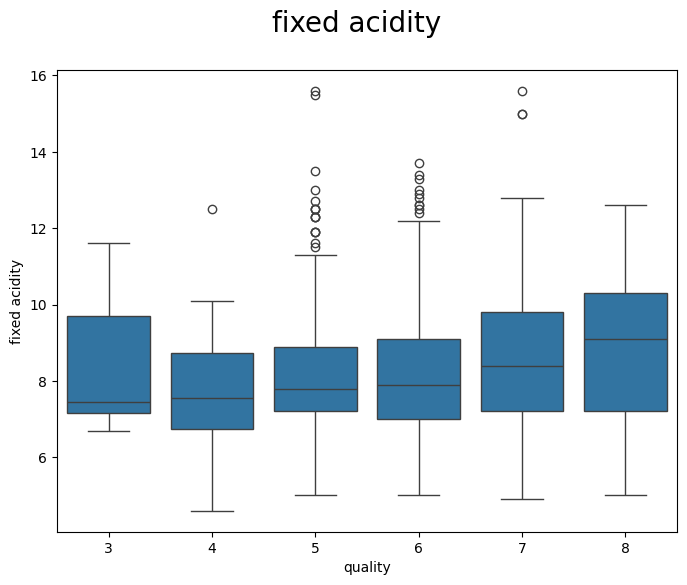

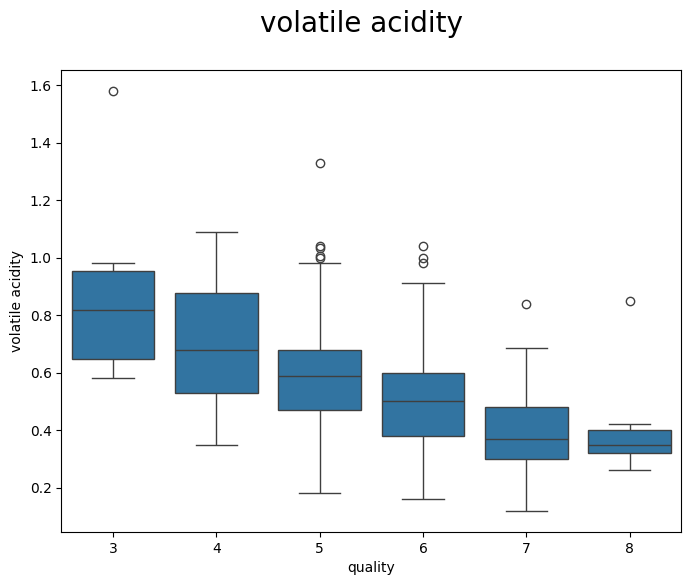

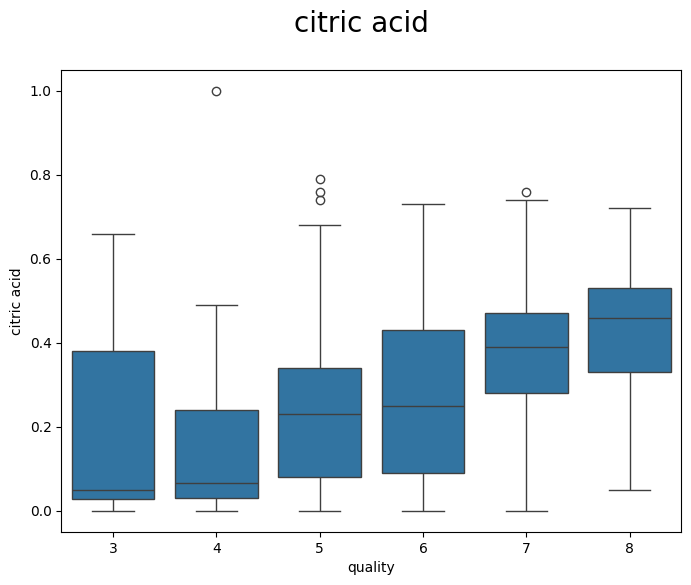

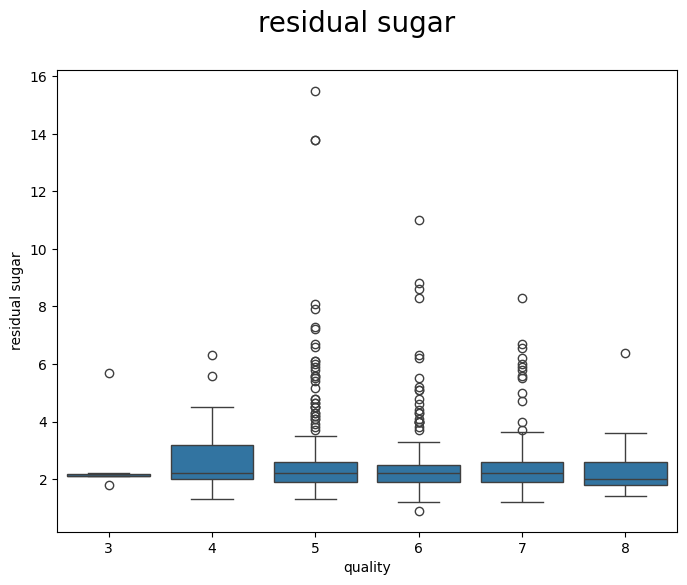

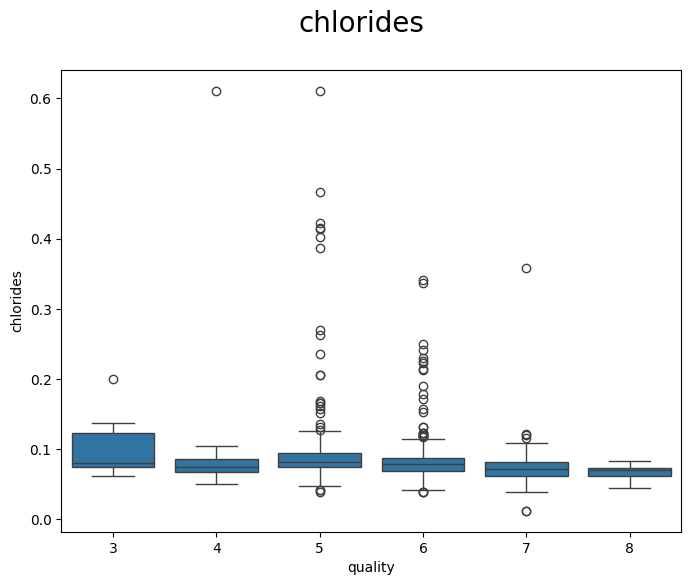

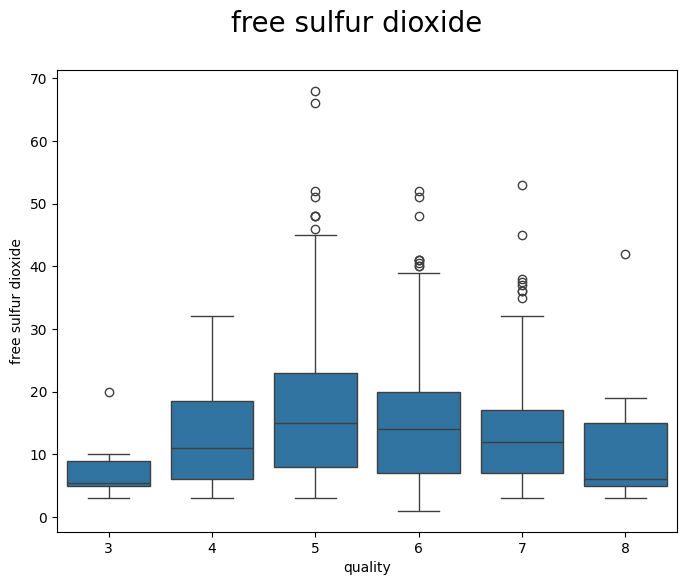

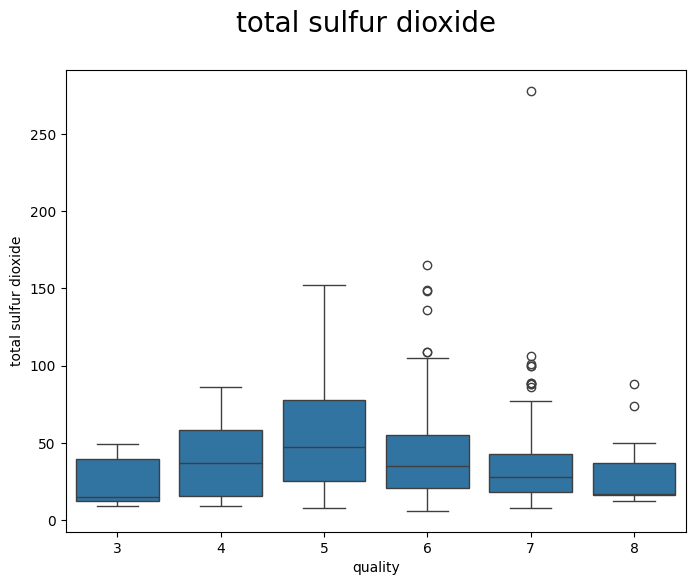

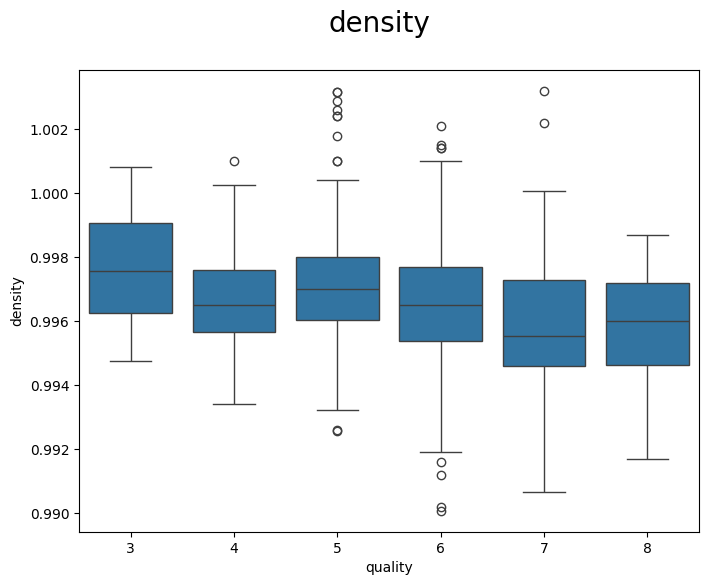

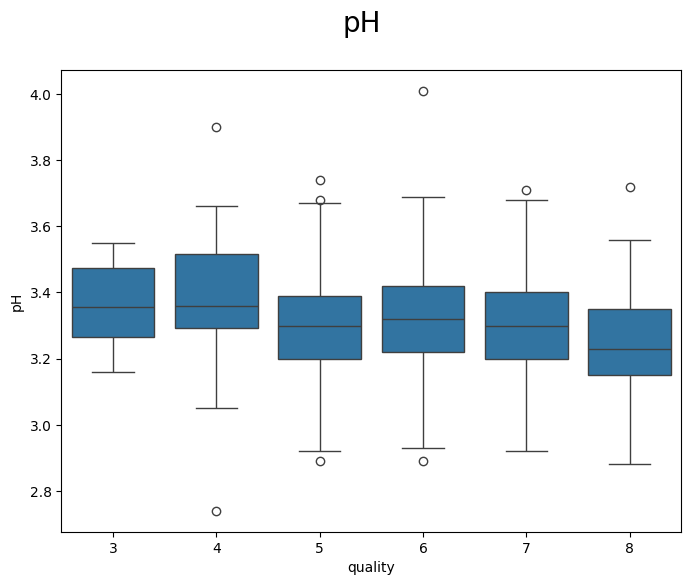

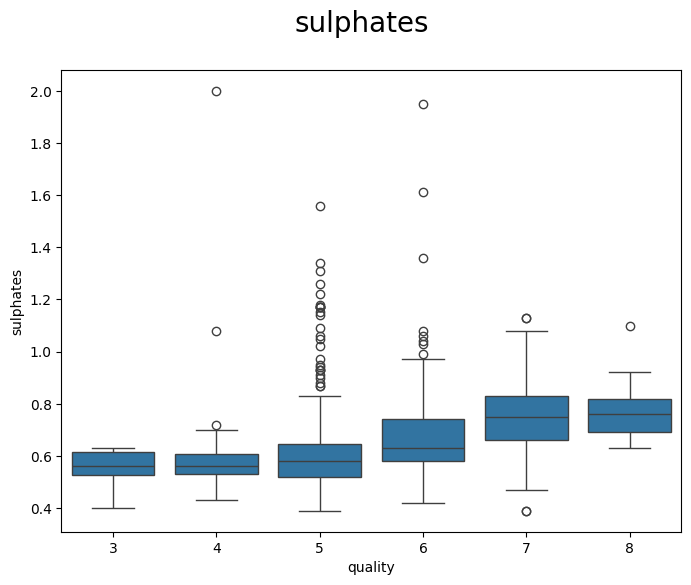

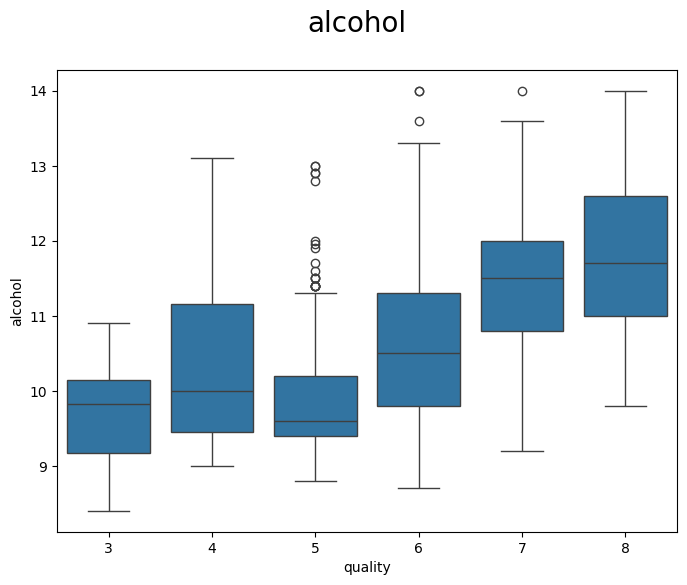

In [28]:
# Mencari fitur apa saja yang kemungkinan menjadi prediktor yang baik
import matplotlib.pyplot as plt
import seaborn as sns

# Iterasi untuk membuat box plot untuk setiap fitur numerik terhadap kolom 'quality'
numerical_features = df.select_dtypes(include=np.number).columns.drop(['quality', 'Id'])

for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    plt.suptitle(feature, fontsize=20)
    sns.boxplot(data=df, y=feature, x='quality')
    plt.show()

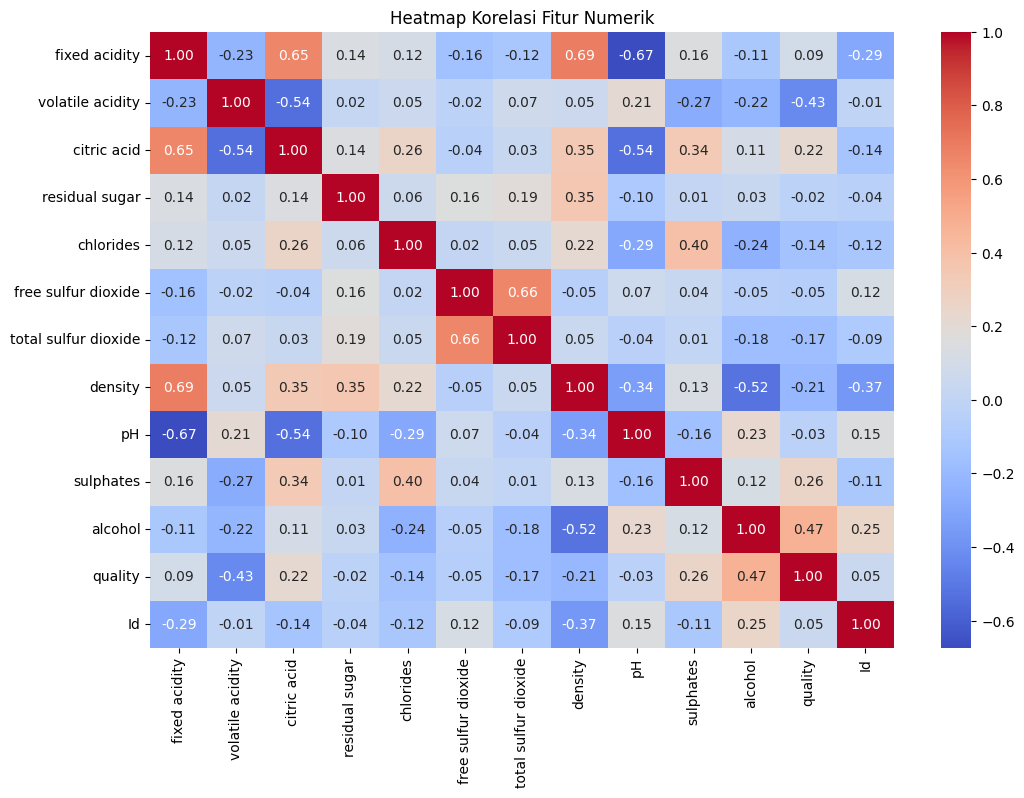

In [29]:
# Hitung matriks korelasi
correlation_matrix = df.corr()

# Plot heatmap dari matriks korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

Random Forest Training Accuracy (max_depth=5): 0.710618
Random Forest Training Precision (max_depth=5): 0.689999
Random Forest Training Recall (max_depth=5): 0.710618
Random Forest Training F1-score (max_depth=5): 0.686340


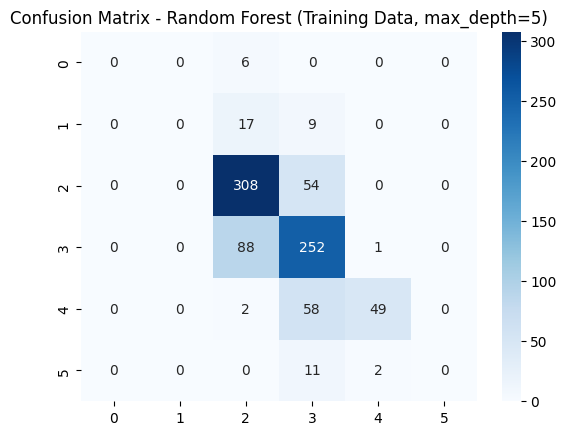

In [52]:
# Membuat model Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Inisialisasi dan pelatihan model Random Forest
# Added max_depth to prevent overfitting on training data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X, y)

# Evaluasi model (pada data training)
rf_y_pred_train = rf_model.predict(X)

accuracy_train = accuracy_score(y, rf_y_pred_train)
precision_train = precision_score(y, rf_y_pred_train, average='weighted')
recall_train = recall_score(y, rf_y_pred_train, average='weighted')
f1_train = f1_score(y, rf_y_pred_train, average='weighted')

print(f"Random Forest Training Accuracy (max_depth=5): {accuracy_train:.6f}")
print(f"Random Forest Training Precision (max_depth=5): {precision_train:.6f}")
print(f"Random Forest Training Recall (max_depth=5): {recall_train:.6f}")
print(f"Random Forest Training F1-score (max_depth=5): {f1_train:.6f}")

# Gunakan model Random Forest (rf_model) untuk membuat predictions pada data pengujian
rf_y_pred_test = rf_model.predict(test_data_features)

# Confusion Matrix untuk Random Forest (Training Data)
rf_conf_matrix_train = confusion_matrix(y, rf_y_pred_train)
sns.heatmap(rf_conf_matrix_train, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest (Training Data, max_depth=5)")
plt.show()

Decision Tree Training Accuracy (max_depth=5): 0.659277
Decision Tree Training Precision (max_depth=5): 0.664138
Decision Tree Training Recall (max_depth=5): 0.659277
Decision Tree Training F1-score (max_depth=5): 0.646460


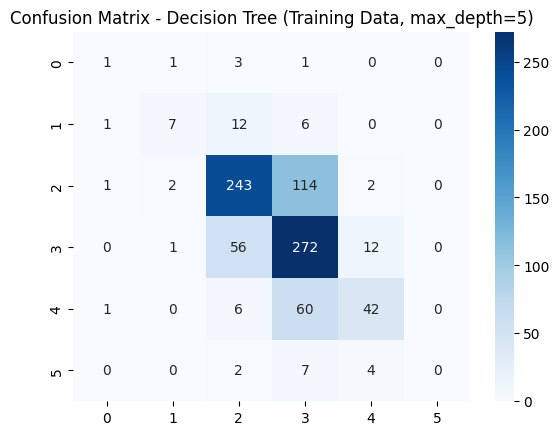

In [53]:
# Membuat model Decision Tree
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import joblib # Ensure joblib is imported if used later
import seaborn as sns
import matplotlib.pyplot as plt

# joblib.dump(dt_model, 'dt_model.pkl') # This line might cause an error if dt_model is not defined yet

# Inisialisasi dan pelatihan model Decision Tree
# Added max_depth to prevent overfitting on training data
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X, y) # Use full training data

# Evaluasi model (pada data training)
dt_y_pred_train = dt_model.predict(X) # Evaluate on full training data

accuracy_train = accuracy_score(y, dt_y_pred_train)
precision_train = precision_score(y, dt_y_pred_train, average='weighted')
recall_train = recall_score(y, dt_y_pred_train, average='weighted')
f1_train = f1_score(y, dt_y_pred_train, average='weighted')

print(f"Decision Tree Training Accuracy (max_depth=5): {accuracy_train:.6f}")
print(f"Decision Tree Training Precision (max_depth=5): {precision_train:.6f}")
print(f"Decision Tree Training Recall (max_depth=5): {recall_train:.6f}")
print(f"Decision Tree Training F1-score (max_depth=5): {f1_train:.6f}")

# Use Decision Tree model (dt_model) to make predictions on test data
dt_y_pred_test = dt_model.predict(test_data_features) # Use test_data_features

# Confusion Matrix for Decision Tree (on training data)
dt_conf_matrix_train = confusion_matrix(y, dt_y_pred_train)
sns.heatmap(dt_conf_matrix_train, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree (Training Data, max_depth=5)")
plt.show()

Naive Bayes Training Accuracy: 0.555426
Naive Bayes Training Precision: 0.573350
Naive Bayes Training Recall: 0.555426
Naive Bayes Training F1-score: 0.557106


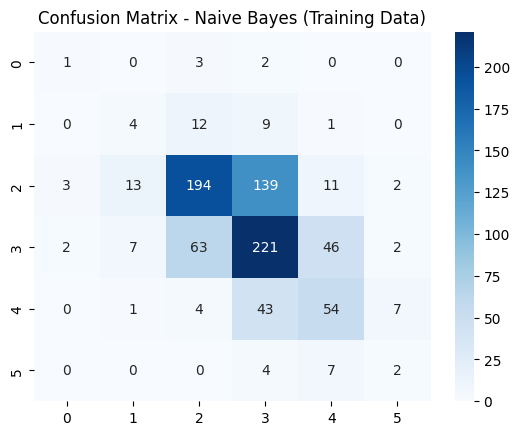

In [54]:
# Inisialisasi dan pelatihan model Naive Bayes
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

nb_model = GaussianNB()
nb_model.fit(X, y) # Use full training data

# Evaluasi model (pada data training)
nb_y_pred_train = nb_model.predict(X) # Evaluate on full training data

accuracy_train = accuracy_score(y, nb_y_pred_train)
precision_train = precision_score(y, nb_y_pred_train, average='weighted')
recall_train = recall_score(y, nb_y_pred_train, average='weighted')
f1_train = f1_score(y, nb_y_pred_train, average='weighted')

print(f"Naive Bayes Training Accuracy: {accuracy_train:.6f}")
print(f"Naive Bayes Training Precision: {precision_train:.6f}")
print(f"Naive Bayes Training Recall: {recall_train:.6f}")
print(f"Naive Bayes Training F1-score: {f1_train:.6f}")

# Use Naive Bayes model (nb_model) to make predictions on test data
nb_y_pred_test = nb_model.predict(test_data_features) # Use test_data_features

# Confusion Matrix for Naive Bayes (on training data)
nb_conf_matrix_train = confusion_matrix(y, nb_y_pred_train)
sns.heatmap(nb_conf_matrix_train, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes (Training Data)")
plt.show()

In [56]:
#Uji data testing
# Meng-upload data testing
test_data = pd.read_csv('/content/data_testing.csv')  # Ganti dengan file testing Anda

# Hapus kolom 'Id' dari data testing agar sesuai dengan fitur yang digunakan saat pelatihan
test_data_features = test_data.drop(columns='Id')

# Memprediksi data testing menggunakan Random Forest
rf_test_pred = rf_model.predict(test_data_features)

# Memprediksi data testing menggunakan Decision Tree
dt_test_pred = dt_model.predict(test_data_features)

# Memprediksi data testing menggunakan Naive Bayes
nb_test_pred = nb_model.predict(test_data_features)

# Menyimpan hasil prediksi pada file CSV (ID dan hasil prediksi)
results = pd.DataFrame({
    'Id': test_data['Id'],  # Pastikan ada kolom 'Id' pada data testing Anda
    'Random Forest Quality Prediction': rf_test_pred,
    'Decision Tree Quality Prediction': dt_test_pred,
    'Naive Bayes Quality Prediction': nb_test_pred
})

# Simpan hasil prediksi ke file CSV di direktori /content/
results.to_csv('/content/hasil_prediksi_quality.csv', index=False)

print("Prediksi selesai, hasil disimpan di '/content/hasil_prediksi_quality.csv'")

Prediksi selesai, hasil disimpan di '/content/hasil_prediksi_quality.csv'
